## Multicellular factor analysis informed by biological prior knowledge with MuVI

---
**NOTE**  
This notebook assumes familiarity with multicellular factor analysis and pathway activity inference.

---

In previous vignettes, we have shown how multicellular coordination can be inferred from pathway activities directly. However, this assumes that your prior knowledge captures all the variability you care about. This has certain limitations: 

- gene sets used to infer activities are not independent, duplicating information
- gene sets are not context specific

What if you would like to use biological prior knowledge to inform factor reconstruction, but at the same time let the model find other sources of variability? Here, we show how to build these type of models with **[MuVI (Multi-View latent variable modeling with domain-informed priors)](https://proceedings.mlr.press/v206/qoku23a.html)** .

---

### Core idea

MUVI extends multi-view factor analysis by incorporating **prior knowledge directly into the factor loadings**, enabling the model to align latent factors with predefined feature sets such as pathways.

In this setting:

- each view represents a cell type or compartment  
- features correspond to **genes**  
- prior knowledge defines relationships between genes, pathways and latent factors  

The model learns:
- **guiding latent factors** informed by pathway annotations (which can be updated). This results in factors that are **directly interpretable as pathway-level programs**, rather than requiring post hoc enrichment analysis.
- **unguided latent factors** capturing coordinated variation across samples and views not dependent on annotations

---

### Why MUVI for pathway-based analysis?

Unlike standard factor models, MUVI introduces **structured sparsity and domain-informed priors** on the loadings:

- factors are encouraged to align with predefined pathways  
- irrelevant features are shrunk toward zero  
- prior knowledge is used to guide interpretation, while remaining robust to noise or misspecification  

This provides:
- improved interpretability of latent factors  
- more stable recovery of biological signals  
- reduced need for downstream enrichment steps 

A limitation of this model, however, is that gene sets can only contain features changing in the same direction. Meaning, that weighted gene sets can't be directly used.

---

### Relation to standard multicellular factor analysis

Conceptually, this framework follows the same structure as multicellular factor analysis:

- samples are represented across multiple views (cell types)  
- variation is decomposed into latent factors  

However, MUVI introduces an additional layer:

- **priors on loadings link factors to pathways**  
- factors are therefore **annotated during model training**, not after  

This shifts the interpretation from:
- *gene-level variation → post hoc pathway enrichment*  

to:
- *pathway-level variation → directly encoded in the model*  

---


In [10]:
import numpy as np
import pandas as pd
import anndata as ad
import decoupler as dc
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scanpy as sc
import mudata as md
import mofaflex as mf
import os
import mina

---

### Application to PBMC data

To illustrate the use of pathway information for multicellular modeling, here we apply MINA to a dataset of peripheral blood mononuclear cells (PBMCs) of eight individuals. In this dataset cells were sequenced before and after treatment with interferon beta ([Kang, et al., 2018](https://www.nature.com/articles/nbt.4042)).

Interferon beta is a type I interferon that signals through the Janus kinase/signal transducer and activator of transcription (JAK-STAT) pathway to trigger antiviral, antiproliferative, and immunomodulatory effects. 

In [PROGENy](https://www.nature.com/articles/s41467-017-02391-6) we have the gene expression changes caused by the stimulation of JAK-STAT, thus it is safe to assume that if we build a multicellular factor analysis guided by the knowledge encoded in these pathways, we should be able to recover factors encoding JAK-STAT that at the same time capture stimulation.

The code below shows the usual processing steps needed for this analysis

In [11]:
adata = ad.read_h5ad("data/kang.h5ad")
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sample_key = 'replicate'
condition_key = 'label'
groupby = 'cell_type'

# create biosample_id by merging sample_key and condition_key
adata.obs[sample_key] = adata.obs[sample_key].astype(str)
adata.obs[condition_key] = adata.obs[condition_key].astype(str)
adata.obs["biosample_id"] = adata.obs[sample_key] + "_" + adata.obs[condition_key]

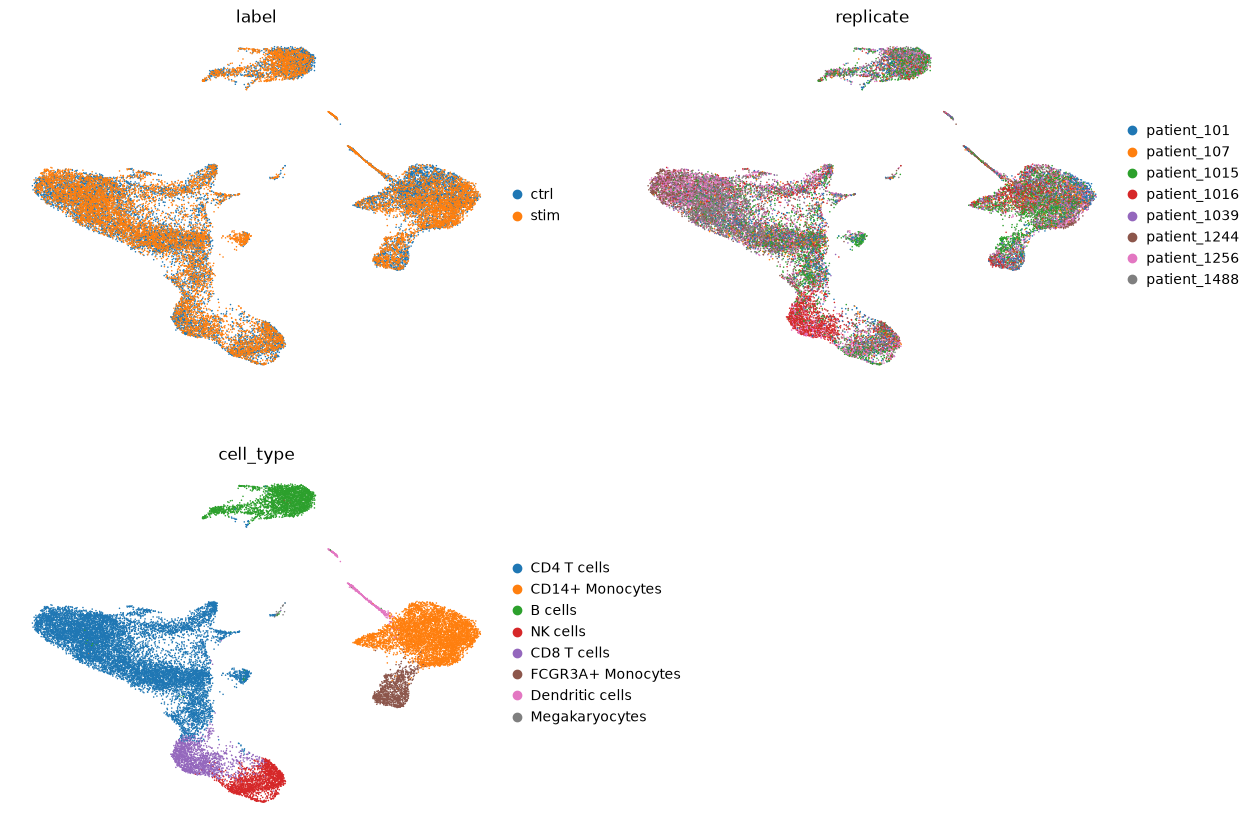

In [12]:
sc.pl.umap(adata, color=[condition_key, sample_key, groupby], frameon=False, ncols=2)


In [13]:
metadata = mina.up.pp.extract_metadata_from_obs(obs = adata.obs,
                                        groupby= 'biosample_id', 
                                        sort= False)

pdata = dc.pp.pseudobulk(adata, sample_col='biosample_id', groups_col="cell_type")

# Manipulations on pdata
pdata.obs = pdata.obs.set_index('biosample_id', drop=False)
pdata.obs.index.name = None 

anndata_dict = mina.up.split_anndata_by_celltype(pdata=pdata, grouping="cell_type")

# Adding gene expression total counts - TODO add to upstream as a function

for cell_type, adata in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata.X, "toarray"):
        # Sparse matrix case
        total_counts = adata.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata.X.sum(axis=0)  # numpy array
    
    # Add to .var
    adata.var['total_counts'] = total_counts

mina.up.filt.filter_anndata_by_ncells(anndata_dict, min_cells=10)
# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples =  math.trunc((n_samples * 0.4))
mina.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.filter_genes_byexpr(anndata_dict, min_count=5, min_prop=0.4)
mina.up.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mina.up.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.90)
mina.up.save_raw_counts(anndata_dict, layer_name="raw_counts")
mina.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
mina.up.filter_smpls_by_nview(anndata_dict, min_views = 5)

Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


/var/folders/bh/sfscsy7s6fn3xzz5nl70w34m0000gp/T/ipykernel_41097/596007318.py:8: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['patient_1015_ctrl', 'patient_1015_stim', 'patient_1016_ctrl', 'patient_1016_stim', 'patient_101_ctrl']

    Inferred to be: categorical



## Using decoupler + MuVI to run functional multicellular factor analysis

For this example, we will use the pathway information of JAK-STAT in PROGENy. First, we pick all genes from which we know we should observe an upregulation upon pathway activation. 

In [14]:
progeny = dc.op.progeny(organism="human", top=500)

#Genes upregulated in JAK-STAT pathway
progeny_up = progeny[progeny["weight"] > 0]
progeny_up = progeny_up[progeny_up["source"].isin(["JAK-STAT"])]
progeny_up["source"] = "up_" + progeny_up["source"]


In MINA, we have facilitated the encoding of prior knowledge in the multiview structure, by allowing users to use `decoupler` gene sets obtained from `Omnipath`.

One simply needs to loop over all views and provide the long dataframe with pathway annotations, this will create a membership matrix within each view. The function deals with the overlap of features between your data and the prior

In [15]:
for cell_type, adata in anndata_dict.items():
    mina.up.make_membership_matrix(anndata_dict[cell_type], progeny_up, gene_col="target", pathway_col="source")

In [16]:
anndata_dict["B cells"].varm["pathway_membership"].head()

,up_JAK-STAT
index,
NOC2L,False
HES4,False
ISG15,True
TNFRSF18,False
SDF4,False


Before fitting the model, we need to append the view to the features (no worries, this doesn't break your membership matrix).

In [17]:
mina.up.append_view_to_var(anndata_dict)

### Fitting the model with MOFA-FLEX

Using MUVI requires defining:

- a **prior matrix** linking features (e.g. genes or pathways) to latent factors (encoded in our varm) 
- hyperparameters controlling the strength of the prior (i.e. how strongly factors are encouraged to follow predefined structure)
- Working with positive-only feature loadings
- Working with positive-only

Note how we create `ann_dict` that tells the model which views to guide with which prior. Here, we use the same name but different feature set, because we expect not all genes across all views to be shared. But you can think of any combination of guided knowledge (e.g. one view only, distinct sets per view, etc.)

Here by default we generate a model with one guided factor (JAK-STAT), and one unguided factor.

Other considerations in the model:

- This model outputs positive factors and gene loadings. This facilitates the interpretation since we associate the guiding signature as genes upregulated upon pathway activation.
- We let the model "relearn" the prior we give, this is controlled by the `annotation_confidence=0.75` parameter

---

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1471: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1322: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
WARNING	Device cuda is not available. Using default device: cpu


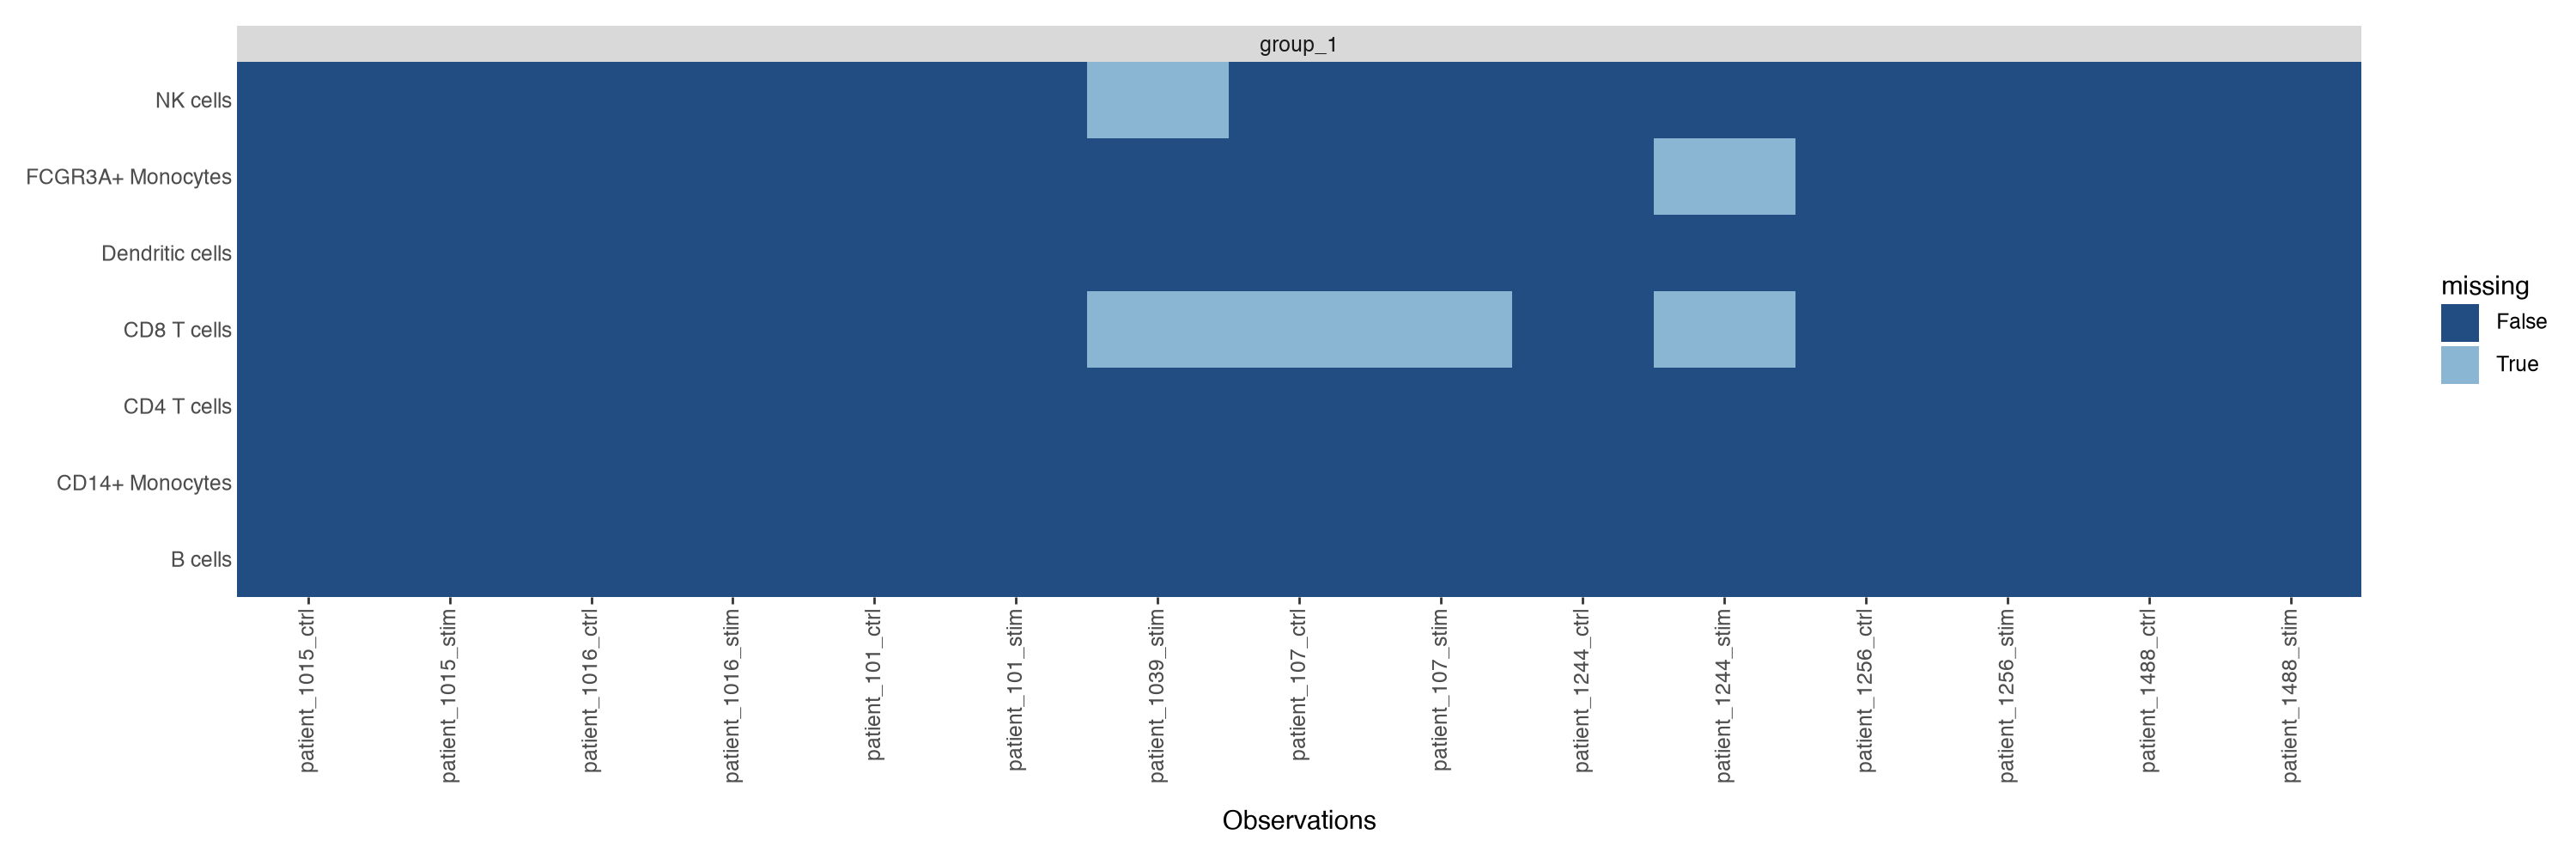

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1471: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1322: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1471: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalit

In [18]:
import mudata as md
import mofaflex as mf

ann_dict = {k: "pathway_membership" for k in anndata_dict}

mdata = md.MuData(anndata_dict)

model = mf.terms.MofaFlex(
    n_factors=1,  # unguided factors
    weight_prior=mf.priors.InformedHorseshoe(
        annotations_varm_key=ann_dict,
        annotation_confidence=0.75,
    ),
    nonnegative_weights=True,
    nonnegative_factors=True,
    init_factors= 0.0
)

model.fit(
    mdata,
    likelihoods="Normal",
    seed=42,
    save_path=False,
    lr=0.001,
    early_stopper_patience=1000,
)

### Outputs of a factor model

A factor model decomposes the data into **latent factors** (capturing sample-level variation) and **loadings** (capturing feature-level contributions), summarizing the main sources of variability.

This is unchanged from the basic workflow. Guided models produce the same outputs (factor scores, explained variance, and loadings), so all downstream functions in MINA can be applied in the same way.

In [19]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)

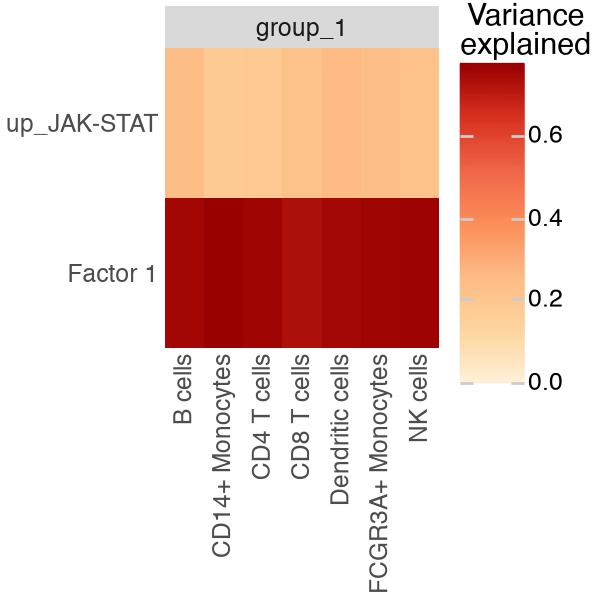

In [20]:
mf.pl.variance_explained(model, figsize=(3, 3))

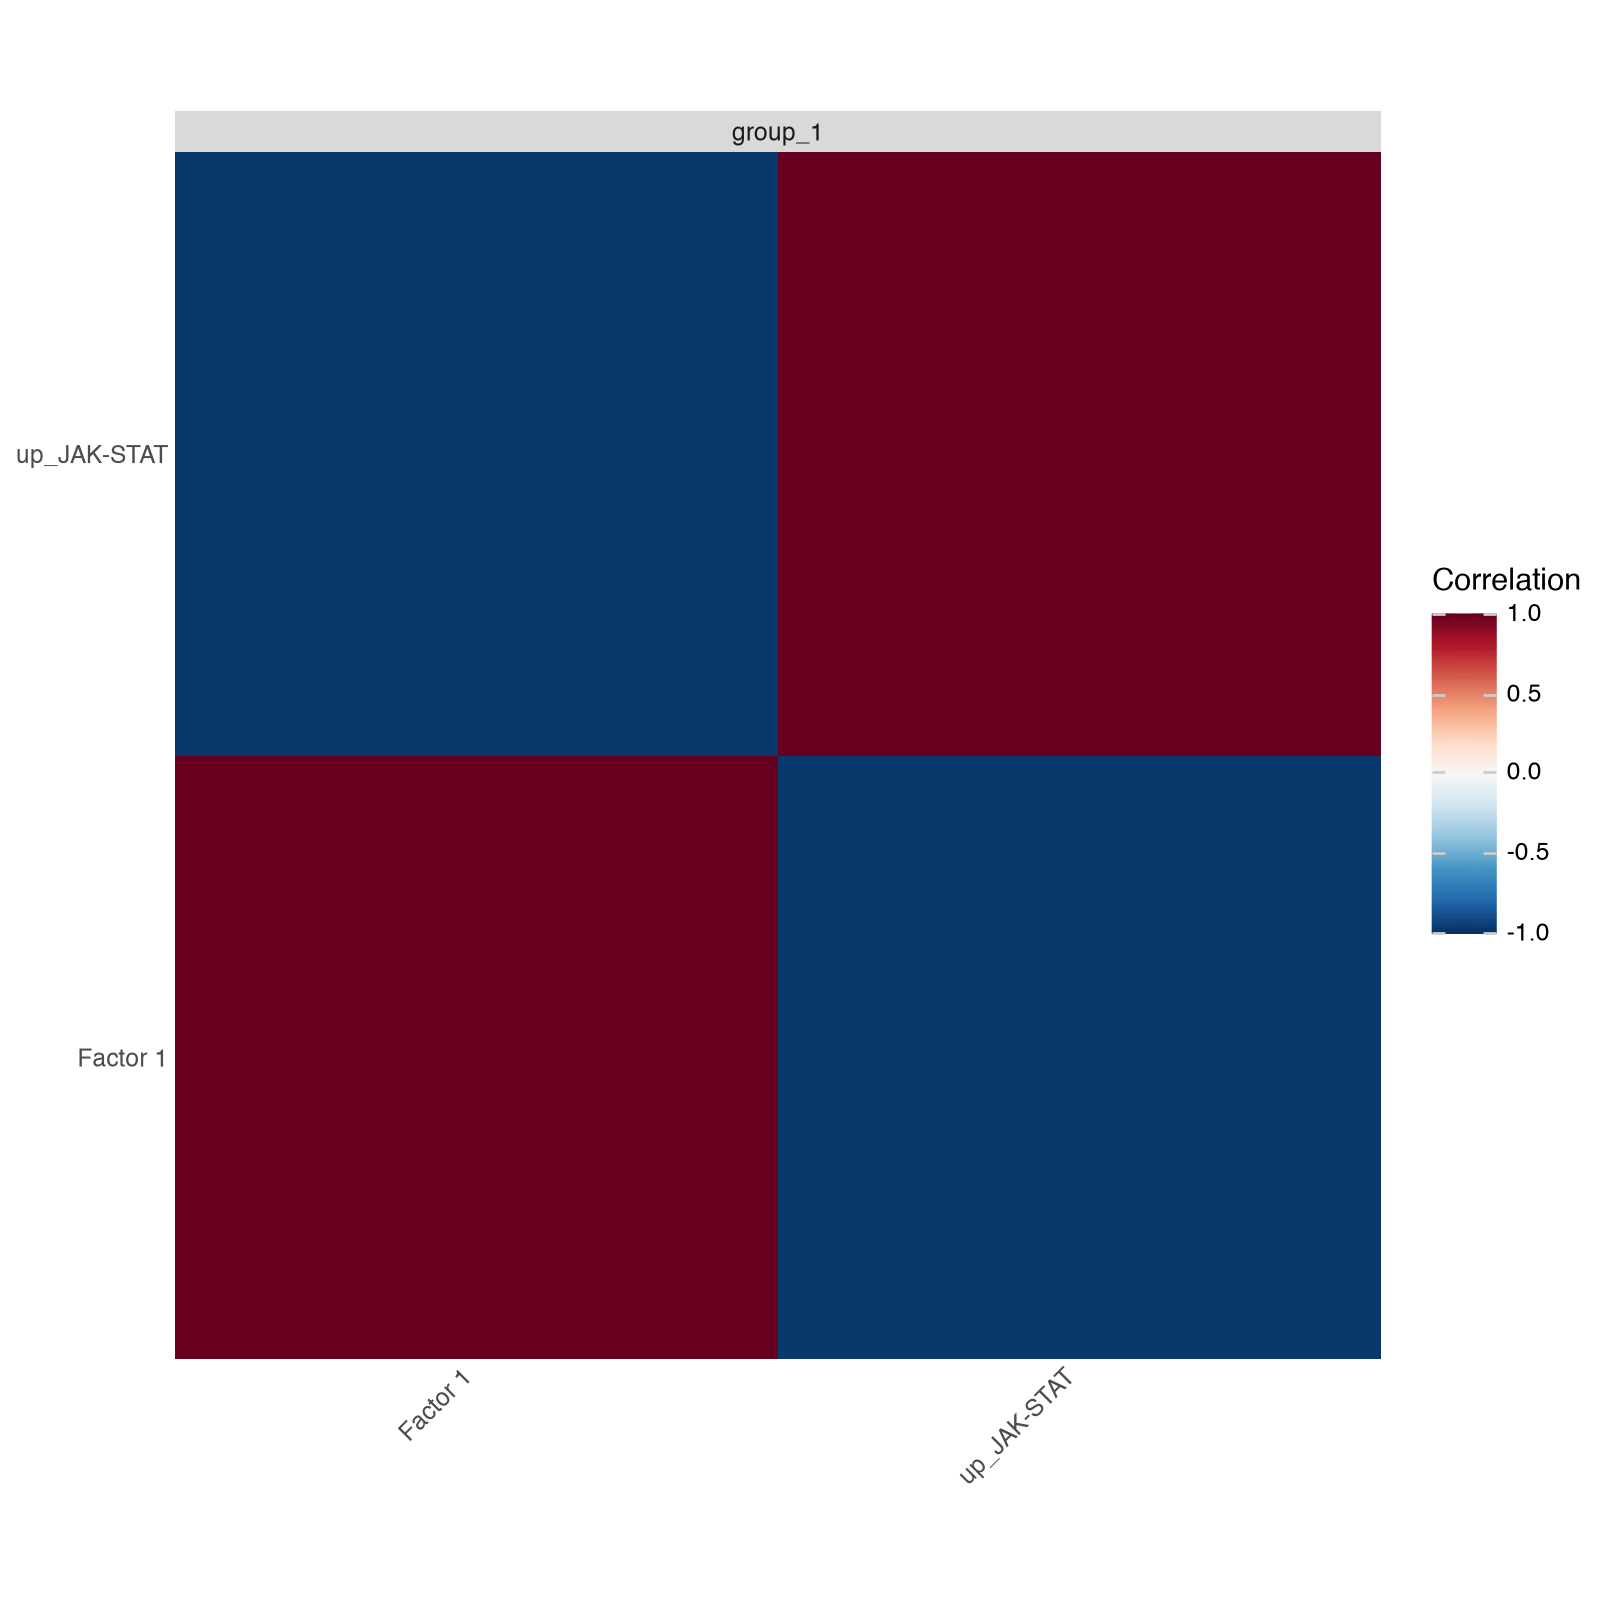

In [21]:
mf.pl.factor_correlation(model)

In the same way as we mentioned in previous vignettes. An important aspect of guided models is to verify the amount of explained variance associated with the guided factors

In [22]:
# Mean by rows
np.mean(amodel.var,axis=1).sort_values(ascending=False).head(10)

Factor1              0.758032
Factorup_JAK-STAT    0.225851
dtype: float64

A limited variability is explained with our guided factors, so interpretation needs to be taken carefully.

In [23]:
amodel.var

,B cells:group_1,CD14+ Monocytes:group_1,CD4 T cells:group_1,CD8 T cells:group_1,Dendritic cells:group_1,FCGR3A+ Monocytes:group_1,NK cells:group_1
Factor1,0.757727,0.774478,0.761197,0.730601,0.753327,0.763577,0.765315
Factorup_JAK-STAT,0.246636,0.182264,0.192161,0.228908,0.260634,0.242120,0.228232


### Associations between pathway activity and stimulated samples

All downstream functions of MINA can be used as before. Let's test our hypothesis that the JAK-STAT factor should separate stimulated from non-stimulated samples

In [24]:
mina.down.get_associations(amodel, 
                           test_variable = "label",
                           test_type="categorical",
                           random_effect = None)

,feature,statistic,p_value,adj_p_value
0,Factor1,209.752380,2.126622e-09,2.126622e-09
1,Factorup_JAK-STAT,820.154663,3.940010e-13,7.880020e-13


The "up" factor refers to genes upregulated upon pathway activation 

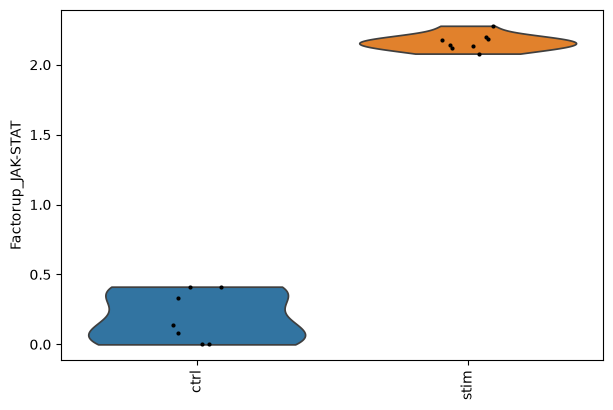

In [ ]:
sc.pl.violin(amodel,
             ["Factorup_JAK-STAT"], 
             groupby="label", rotation=90,size = 3,
             dodge = False)

As expected the JAK-STAT pathway is more active in the stimulated samples. However we also observe that the other unguided factor also separates stimulated from non-stimulated samples.

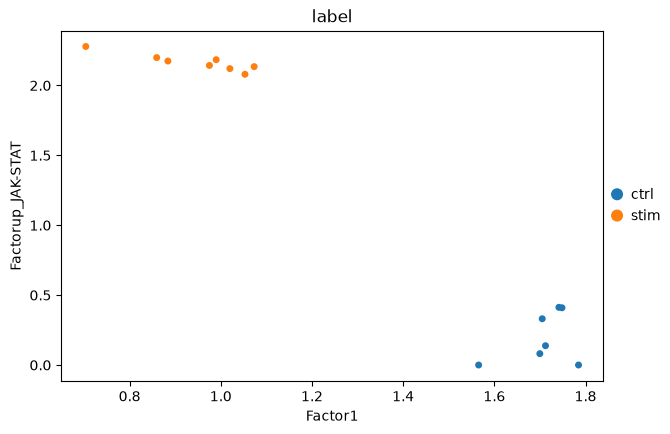

In [26]:
sc.pl.scatter(amodel,
              x = "Factor1",
              y = "Factorup_JAK-STAT", 
              color  = "label", 
              size =100)

Factor 1 and the guided JAK-STAT up factor highly correlate with each other. This correlation stays when looking at stimulated samples, but it dissapears when looking at healthy samples 

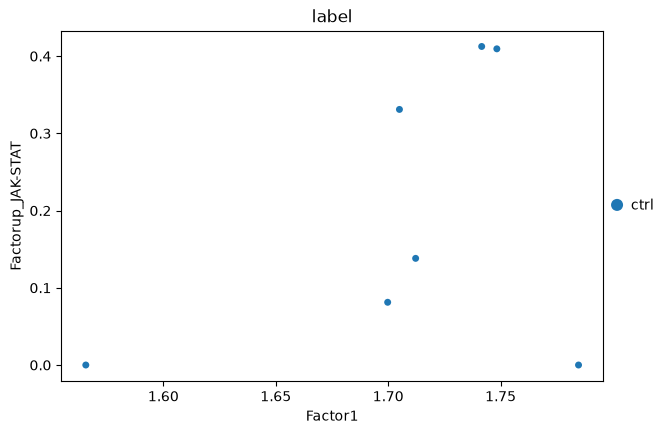

In [27]:
sc.pl.scatter(amodel[amodel.obs["label"] == "ctrl", :],
              x = "Factor1",
              y = "Factorup_JAK-STAT", 
              color  = "label", 
              size =100)

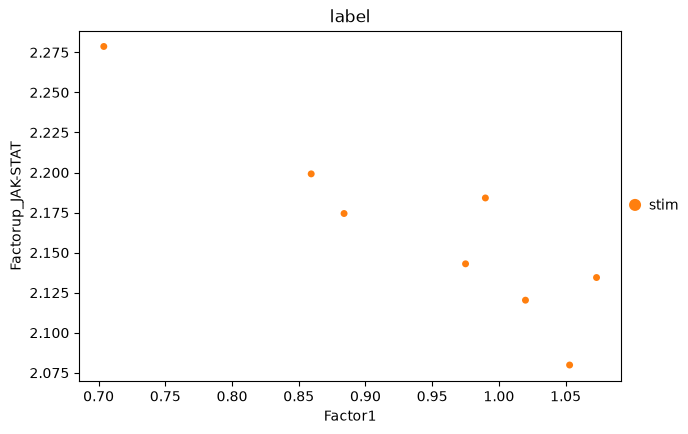

In [28]:
sc.pl.scatter(amodel[amodel.obs["label"] == "stim", :],
              x = "Factor1",
              y = "Factorup_JAK-STAT", 
              color  = "label", 
              size =100)

Running ULM for view: B cells
Running ULM for view: CD14+ Monocytes
Running ULM for view: CD4 T cells
Running ULM for view: CD8 T cells
Running ULM for view: Dendritic cells
Running ULM for view: FCGR3A+ Monocytes
Running ULM for view: NK cells


/Users/flores/Dropbox/EBI/Research/MINA/src/mina/pl/pl.py:483: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


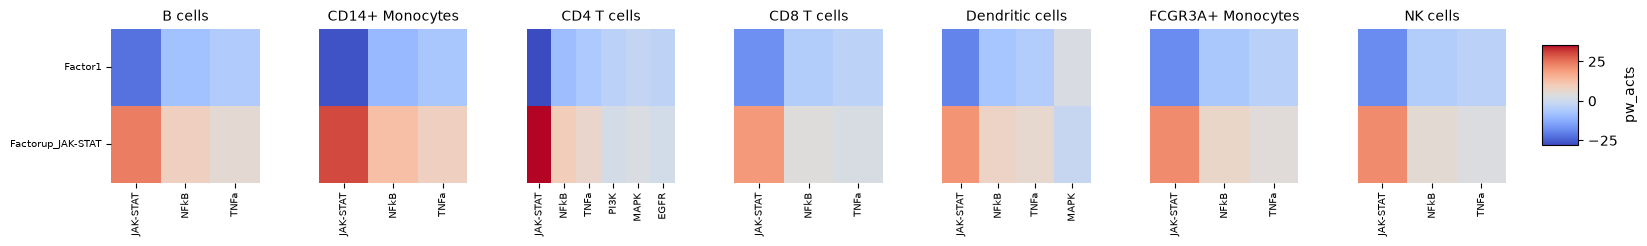

In [30]:
# Characterizing Factor Loadings
# First we need to make the gene loadings a pandas DataFrame with named columns and indexes
# Wrap as DataFrame for readability - This could be a function - users will forget to do this
gene_loadings = pd.DataFrame(amodel.varm["gene_loadings"], columns=amodel.uns['gene_loadings_columns'])
gene_loadings.index = amodel.var.index.to_list()

# Make a dictionary of gene expression data
gene_loadings = mina.down.split_by_view(gene_loadings)

progeny_full = dc.op.progeny(organism="human", top=500)
progeny_pos = progeny_full[progeny_full["weight"] > 0]

# Now you can run decoupler for each matrix of gene loadings
mcp_pws = mina.down.run_ulm_per_view(view_dict=gene_loadings, net=progeny_full)

mina.pl.plot_mcell_funcomics(mcp_pws, 
                     p_threshold=0.05,
                     top_n=15,
                     use_var=True,
                     figsize=(18, 2))

When using the genes that get expressed upon JAK-STAT activation, naturally the genes that are downregulated are added to the extra factor. This example is used for a simple presentation of the model, and we could expect that as more factors are added, this correlation structure may start breaking. 

However, one interesting question we could ask from this model is the "contextualized" perturbation signature obtained in the loadings. During training, the original weights from PROGENy are allowed to slightly change. This is useful when using pathway perturbation signatures that come from a different context. 

From the results above CD4 T cells seem to have the best alignment with the original signatures.

In [34]:
# Get top 10 genes by weight per source
jstat = progeny_full[progeny_full["source"].isin(["JAK-STAT"])]
jstat = jstat[jstat["weight"] > 0]
# Make it absolute and get top 20
jstat["weight"] = jstat["weight"].abs()
# Make the weight of progeny to be max 1
jstat["weight"] = jstat["weight"] / jstat["weight"].max()

top_genes = (
    jstat
    .groupby("source", group_keys=False)
    .apply(lambda x: x.nlargest(10, "weight"))
    .reset_index(drop=True)
)

top_genes_list = top_genes["target"].tolist()

In [35]:
# For each loading matrix in gene_loadings dict
# select the relevant genes (columns) from the top_genes_list and
# the Factorup_JAK-STAT, put all cell_type values in a single matrix

rows = []

for cell_type, loading_matrix in gene_loadings.items():
    # Genes available in this loading matrix
    relevant_genes = [
        gene
        for gene in top_genes_list
        if gene in loading_matrix.columns
    ]

    # Keep as DataFrame, not Series
    temp_mat = loading_matrix.loc[
        ["Factorup_JAK-STAT"],
        relevant_genes,
    ]

    # Replace factor name with cell type
    temp_mat.index = [cell_type]

    rows.append(temp_mat)

top_genes = top_genes[["target", "weight"]]
top_genes.rename(columns={"weight": "PROGENy"}, inplace=True)
top_genes = top_genes.set_index("target")
top_genes = top_genes.transpose()
# Keep as DataFrame, not Series
temp_mat = top_genes.loc[
        ["PROGENy"],
        top_genes_list,]

rows.append(temp_mat)

# Combine all cell types into one matrix
jak_stat_matrix = pd.concat(
    rows,
    axis=0,
).reindex(columns=top_genes_list)


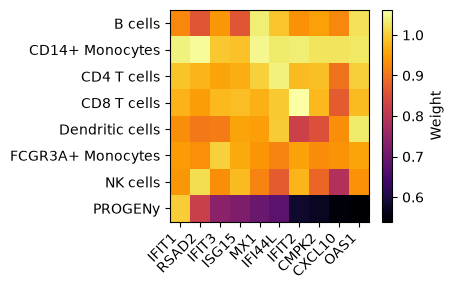

In [33]:
cmap = plt.colormaps["inferno"].copy()
cmap.set_bad("grey")

fig, ax = plt.subplots(figsize=(4.5, 3))

im = ax.imshow(jak_stat_matrix.values, cmap=cmap, aspect="auto", vmin=jak_stat_matrix.min().min())

ax.set_xticks(range(len(jak_stat_matrix.columns)))
ax.set_xticklabels(jak_stat_matrix.columns, rotation=45, ha="right")

ax.set_yticks(range(len(jak_stat_matrix.index)))
ax.set_yticklabels(jak_stat_matrix.index)

fig.colorbar(im, ax=ax, label="Weight")

plt.tight_layout()
plt.show()

Comparing the original weights from PROGENy to the ones relearned within model training, we observed that the gene set we used doesn't have a universal fit to all contexts. This is a more realistic use of gene sets, where we use them as an initial prior or reference, and when applied to the right context (in this case interferon stimulation), it is possible to derive cell-type specific gene sets that could be used in other contexts. 

## Summary

This notebook shows how MINA interfaces between prior knowledge databases and enrichment tools via decoupler-py to build the data structures with feature annotations needed by MOFA-FLEX, reducing the friction between available gene sets and modeling tools. A particularly interesting application is to use these models to contextualize pathway activities in multicellular responses.
